In [6]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# 读取清理后的数据
df = pd.read_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/data/student_combined_cleaned.csv")

# 特征和目标
X = df.drop(columns=['G3'])
y = df['G3']

# 对分类特征进行独热编码
X = pd.get_dummies(X)

# 划分训练集（70%用于训练，30%用于评估）
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42)

# 合并特征和目标列
train_data = pd.concat([X_train, y_train], axis=1)

# 保存训练集为csv文件
train_data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_train_data.csv", index=False)

# 训练线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 输出线性回归模型的权重（w）
print("训练完毕，模型权重 (w):", model.coef_)

# 保存训练好的线性回归模型
joblib.dump(model, "E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/linear_regression_model.pkl")

print("训练集数据已保存为 student_train_data.csv，线性回归模型已保存为 linear_regression_model.pkl。")

训练完毕，模型权重 (w): [ 0.01576306 -0.04208146  0.00517905  0.1865674   0.03729292 -0.33063239
  0.07091401  0.04472483 -0.07076004 -0.10189728  0.05992281 -0.04780143
  0.03233268  0.11323949  0.9394679  -0.0115708   0.0115708   0.03715686
 -0.03715686 -0.05217399  0.05217399 -0.05538721  0.05538721  0.0595369
 -0.0595369  -0.2028995   0.27553897 -0.10102762  0.13884227 -0.11045412
  0.12322368  0.11997461 -0.02848506 -0.22023175  0.00551853  0.19704933
  0.0208717  -0.20908997 -0.00883106 -0.14127254 -0.05782512  0.19909766
  0.02800665 -0.02800665 -0.05582487  0.05582487 -0.04895196  0.04895196
 -0.01066674  0.01066674  0.12250301 -0.12250301 -0.06493898  0.06493898
 -0.00866743  0.00866743  0.04444885 -0.04444885 -0.30773945  0.30773945]
训练集数据已保存为 student_train_data.csv，线性回归模型已保存为 linear_regression_model.pkl。


评估集的MSE: 2.8425606020403373
评估集的R²: 0.8104904773998377


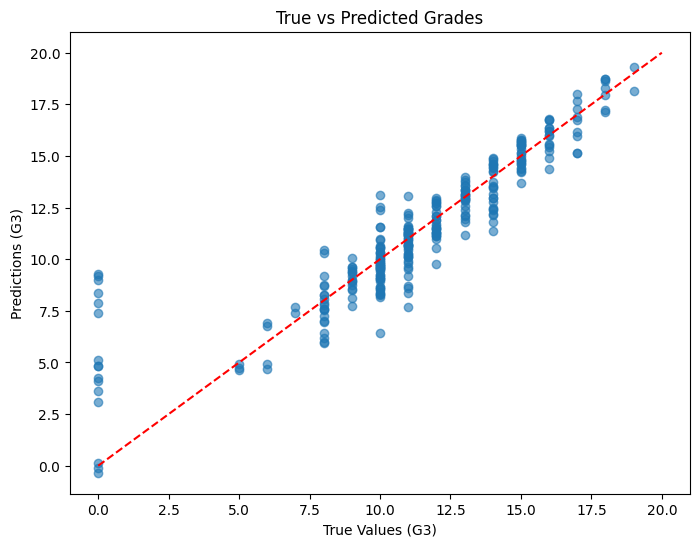

评估集数据已保存为 student_eval_data.csv。


In [10]:
import pandas as pd
import joblib
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 加载训练好的线性回归模型
model = joblib.load("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/linear_regression_model.pkl")

# 读取清理后的数据
df = pd.read_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/data/student_combined_cleaned.csv")

# 特征和目标
X = df.drop(columns=['G3'])
y = df['G3']

# 对分类特征进行独热编码，确保与训练集特征一致
X = pd.get_dummies(X)

# 划分评估集（30%用于评估）
_, X_eval, _, y_eval = train_test_split(X, y, test_size=0.3, random_state=42)

# 合并评估集的特征和目标列
eval_data = pd.concat([X_eval, y_eval], axis=1)

# 保存评估集为csv文件
eval_data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_eval_data.csv", index=False)

# 使测试数据与训练数据的特征一致，填补缺失的列（如果有）
X_eval = X_eval.reindex(columns=model.feature_names_in_, fill_value=0)

# 预测评估集
y_pred = model.predict(X_eval)

# 评估模型
mse = mean_squared_error(y_eval, y_pred)
r2 = r2_score(y_eval, y_pred)

# 打印评估结果
print("评估集的MSE:", mse)
print("评估集的R²:", r2)

# 可视化预测结果
plt.figure(figsize=(8, 6))
plt.scatter(y_eval, y_pred, alpha=0.6)
plt.plot([0, 20], [0, 20], color='red', linestyle='--')  # 绘制理想的完美拟合线
plt.xlabel("True Values (G3)")
plt.ylabel("Predictions (G3)")
plt.title("True vs Predicted Grades")
plt.show()

print("评估集数据已保存为 student_eval_data.csv。")

In [11]:
import pandas as pd
import os

# 读取清理后的数据
df = pd.read_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/data/student_combined_cleaned.csv")

# 选择需要的特征和目标变量
X = df[['Medu', 'Fedu', 'studytime', 'famrel']]  # 选择特征
y = df['G3']  # G3作为目标变量

# 合并特征和目标变量，生成数据文件
data = pd.concat([X, y], axis=1)

# 保存包含特征和目标变量的数据文件
data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_data_with_G3.csv", index=False)

# 输出生成的文件路径
print("数据文件已保存为 student_data_with_G3.csv。")

数据文件已保存为 student_data_with_G3.csv。


In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import joblib
import os

# 读取清理后的数据
df = pd.read_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/data/student_combined_cleaned.csv")

# 选择特征和目标变量
X = df[['Medu', 'Fedu', 'studytime', 'famrel']]  # 选择特征
y = df['G3']  # G3作为目标变量

# 划分数据集：70%用于训练，30%用于评估
X_train, _, y_train, _ = train_test_split(X, y, test_size=0.3, random_state=42)

# 合并训练集数据并保存
train_data = pd.concat([X_train, y_train], axis=1)
train_data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_train_data_with_G3.csv", index=False)

# 训练线性回归模型
model = LinearRegression()
model.fit(X_train, y_train)

# 输出模型的权重
print("训练完毕，模型权重 (w):", model.coef_)

# 确保模型保存的目录存在
if not os.path.exists('models'):
    os.makedirs('models')

# 保存训练好的线性回归模型
joblib.dump(model, "E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/linear_regression_model_with_G3.pkl")

print("训练集数据已保存为 student_train_data_with_G3.csv，线性回归模型已保存为 linear_regression_model_with_G3.pkl。")

训练完毕，模型权重 (w): [0.34942217 0.35231516 0.95508059 0.10795267]
训练集数据已保存为 student_train_data_with_G3.csv，线性回归模型已保存为 linear_regression_model_with_G3.pkl。


评估集的MSE: 14.66553249248249
评估集的R²: 0.02226954833166117


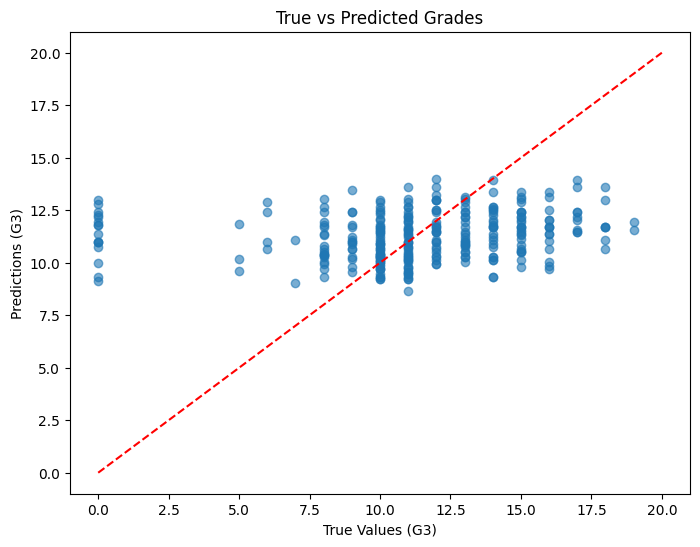

评估集数据已保存为 student_eval_data_with_G3.csv。


In [13]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 加载训练好的模型
model = joblib.load("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/linear_regression_model_with_G3.pkl")

# 读取清理后的数据
df = pd.read_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/data/student_combined_cleaned.csv")

# 选择特征和目标变量
X = df[['Medu', 'Fedu', 'studytime', 'famrel']]  # 选择特征
y = df['G3']  # G3作为目标变量

# 划分数据集：30%用于评估
_, X_eval, _, y_eval = train_test_split(X, y, test_size=0.3, random_state=42)

# 合并评估集数据并保存
eval_data = pd.concat([X_eval, y_eval], axis=1)
eval_data.to_csv("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/10/data/raw/student_eval_data_with_G3.csv", index=False)

# 使评估集特征与训练集一致
X_eval = X_eval.reindex(columns=model.feature_names_in_, fill_value=0)

# 预测评估集
y_pred = model.predict(X_eval)

# 评估模型
mse = mean_squared_error(y_eval, y_pred)
r2 = r2_score(y_eval, y_pred)

# 打印评估结果
print("评估集的MSE:", mse)
print("评估集的R²:", r2)

# 可视化预测结果
plt.figure(figsize=(8, 6))
plt.scatter(y_eval, y_pred, alpha=0.6)
plt.plot([0, 20], [0, 20], color='red', linestyle='--')  # 绘制理想的完美拟合线
plt.xlabel("True Values (G3)")
plt.ylabel("Predictions (G3)")
plt.title("True vs Predicted Grades")
plt.show()

print("评估集数据已保存为 student_eval_data_with_G3.csv。")